# 01 — Exploratory Data Analysis (EDA)

Цель: загрузка, очистка, feature engineering и визуализация датасета **Student Depression Dataset**.

Весь код предобработки вынесен в `src/preprocessing.py`; в этом ноутбуке мы вызываем его функции и анализируем результаты.

## 0. Настройка окружения

In [1]:
import sys
from pathlib import Path

# Добавляем корень проекта в sys.path, чтобы импортировать src/
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Корень проекта: {project_root}')

Корень проекта: c:\Users\User\Desktop\ML2


In [2]:
from src.preprocessing import (
    load_raw_data,
    clean_data,
    engineer_features,
    run_all_plots,
    split_and_save,
    get_paths,
)

paths = get_paths(project_root)
images_dir = paths['images_dir']
images_dir.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

Исходный файл должен лежать по адресу `data/raw/Student Depression Dataset.csv`.

In [3]:
df = load_raw_data(project_root)
df.head()

Датасет загружен: 27901 строк, 18 столбцов.


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 2. Описание датасета

In [4]:
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\nОбщая информация:')
df.info()
print('\nСтатистика:')
display(df.describe())
print('\nРаспределение целевой переменной:')
display(df['Depression'].value_counts(normalize=True).rename('доля'))

Размер датасета: 27901 строк, 18 столбцов

Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration      

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000



Распределение целевой переменной:


Depression
1    0.585499
0    0.414501
Name: доля, dtype: float64

## 3. Очистка данных

Шаги: удаление пропусков → удаление дубликатов → приведение типов.

In [5]:
print('Пропуски до очистки:')
display(df.isnull().sum()[df.isnull().sum() > 0])

df = clean_data(df)

print('\nПропуски после очистки:', df.isnull().sum().sum())

Пропуски до очистки:


Financial Stress    3
dtype: int64

Удалено строк с пропусками: 3
Удалено дубликатов: 0
Итог после очистки: 27898 строк, 18 столбцов.

Пропуски после очистки: 0


## 4. Feature Engineering

Создаём два новых признака:
- **Overall_Pressure** = Academic Pressure + Work Pressure — суммарная нагрузка;
- **Satisfaction_Ratio** = Study Satisfaction / (Job Satisfaction + ε) — соотношение удовлетворённости.

In [6]:
df = engineer_features(df)
df[['Overall_Pressure', 'Satisfaction_Ratio']].describe()

Количество признаков после feature engineering: 18


,Overall_Pressure,Satisfaction_Ratio
count,27898.000000,2.789800e+04
mean,3.141766,2.943688e+06
std,1.381185,1.361294e+06
min,0.000000,0.000000e+00
25%,2.000000,2.000000e+06
50%,3.000000,3.000000e+06
75%,4.000000,4.000000e+06
max,5.000000,5.000000e+06


## 5. Визуализации

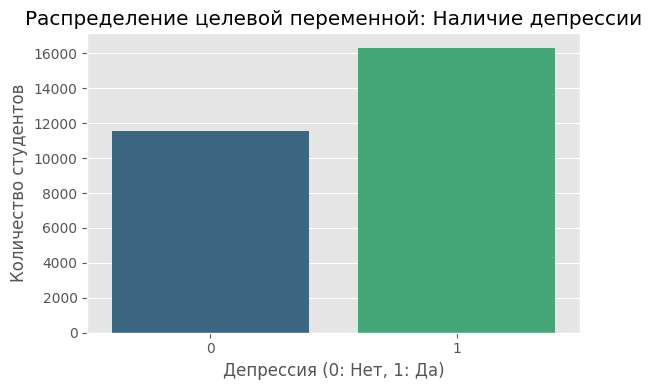

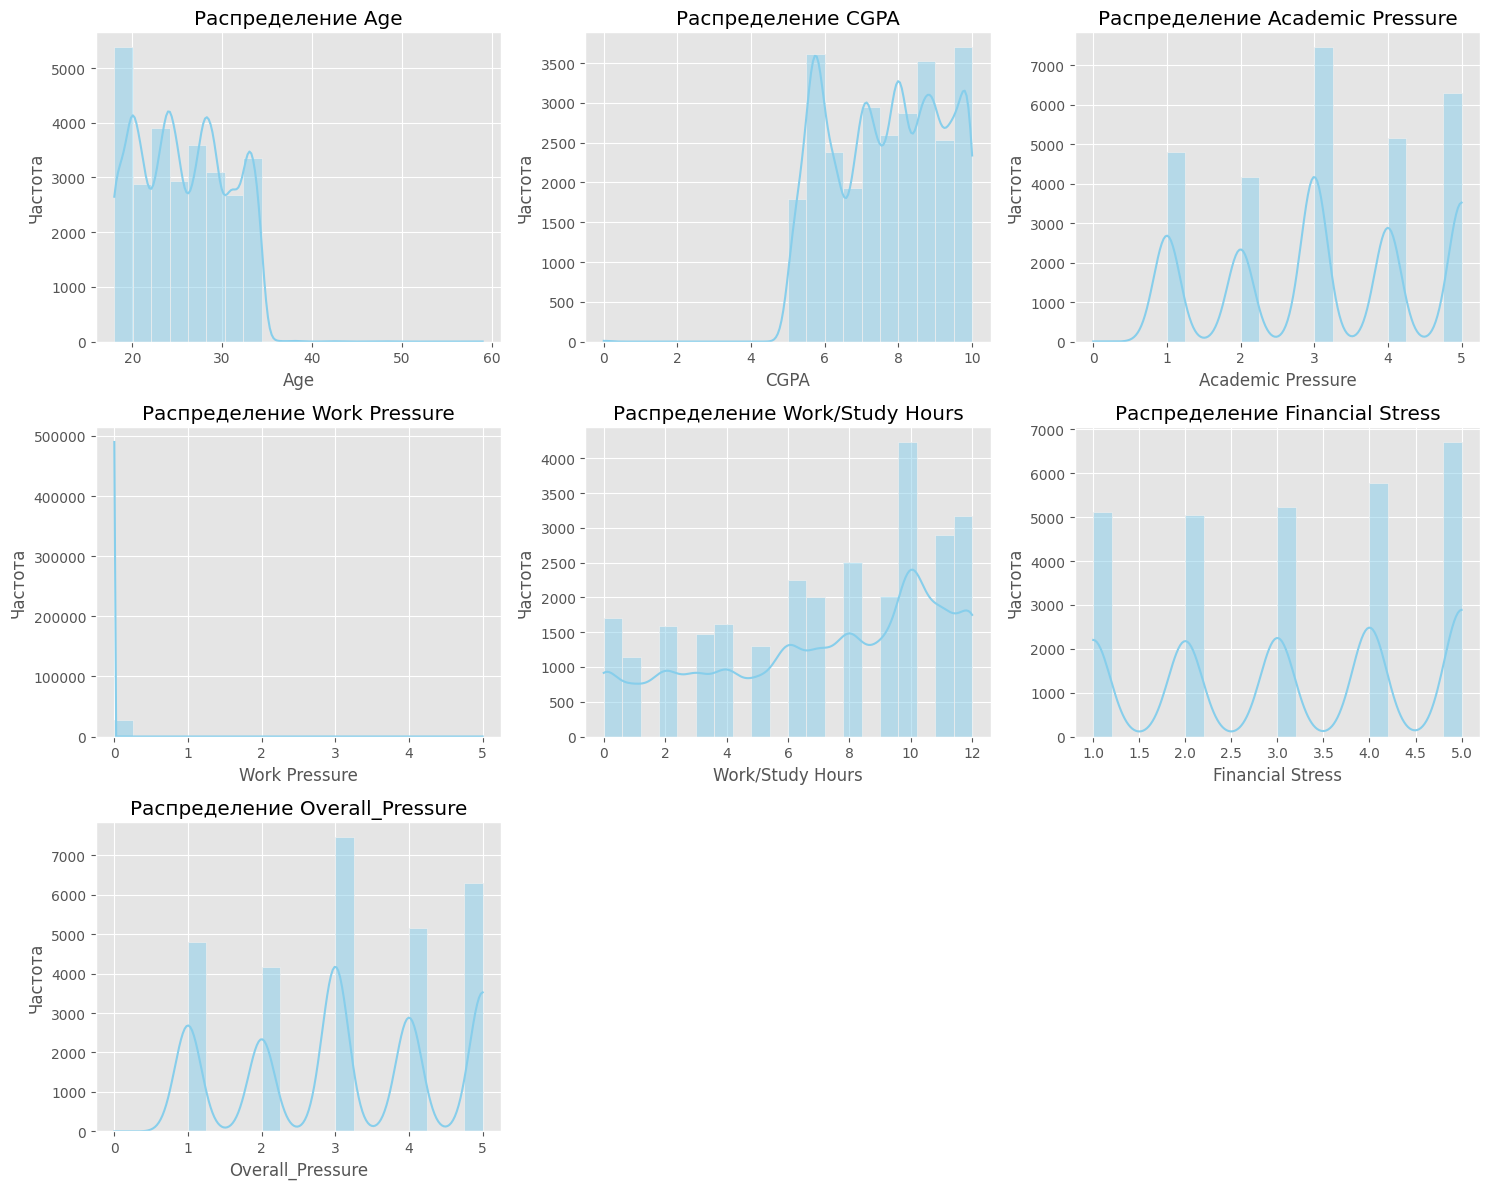

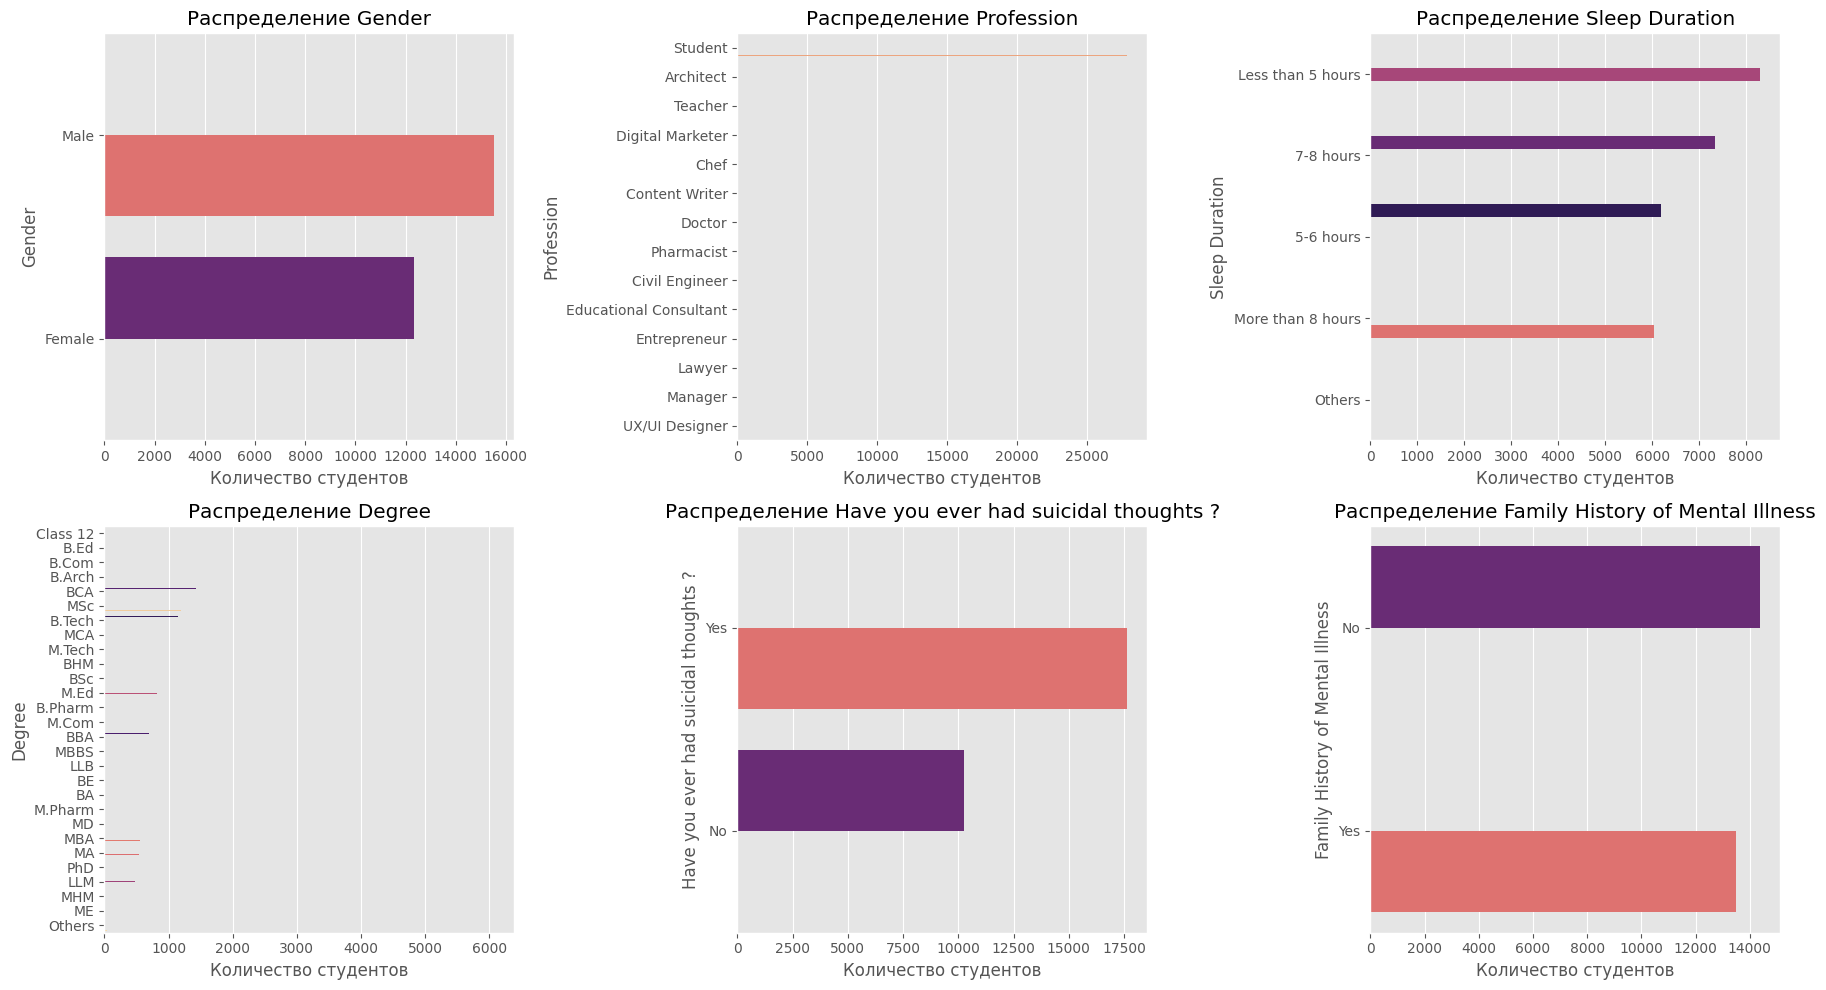

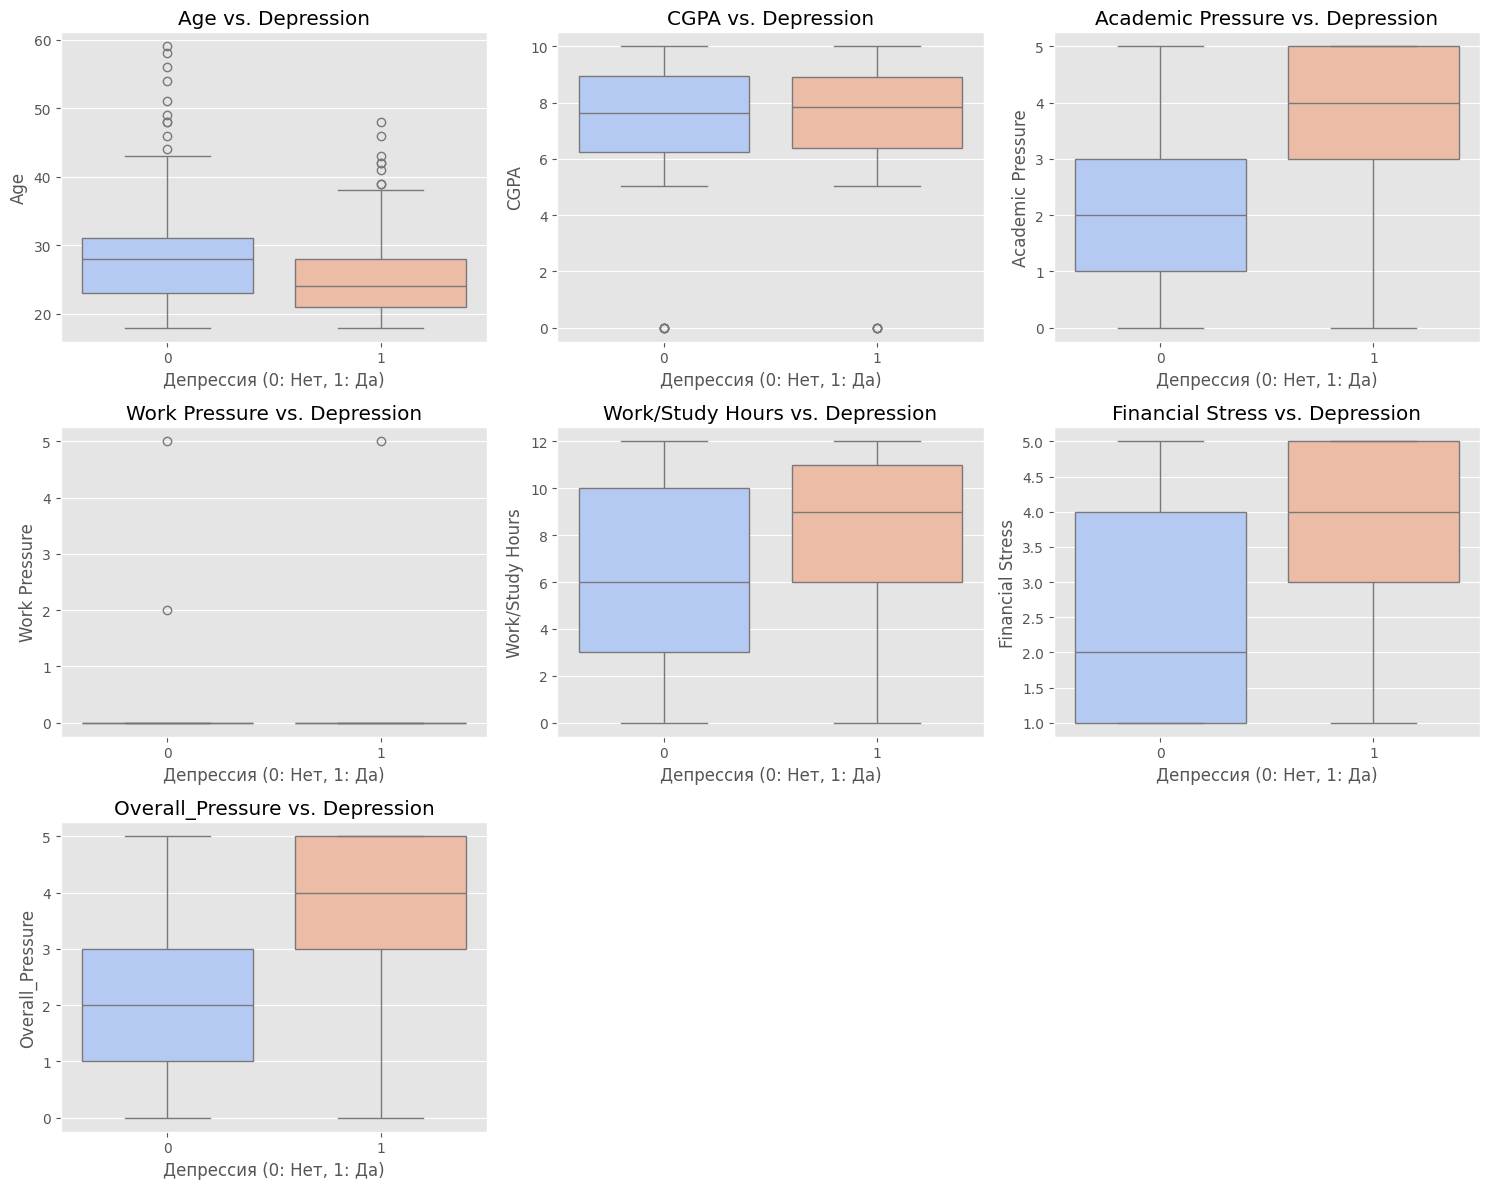

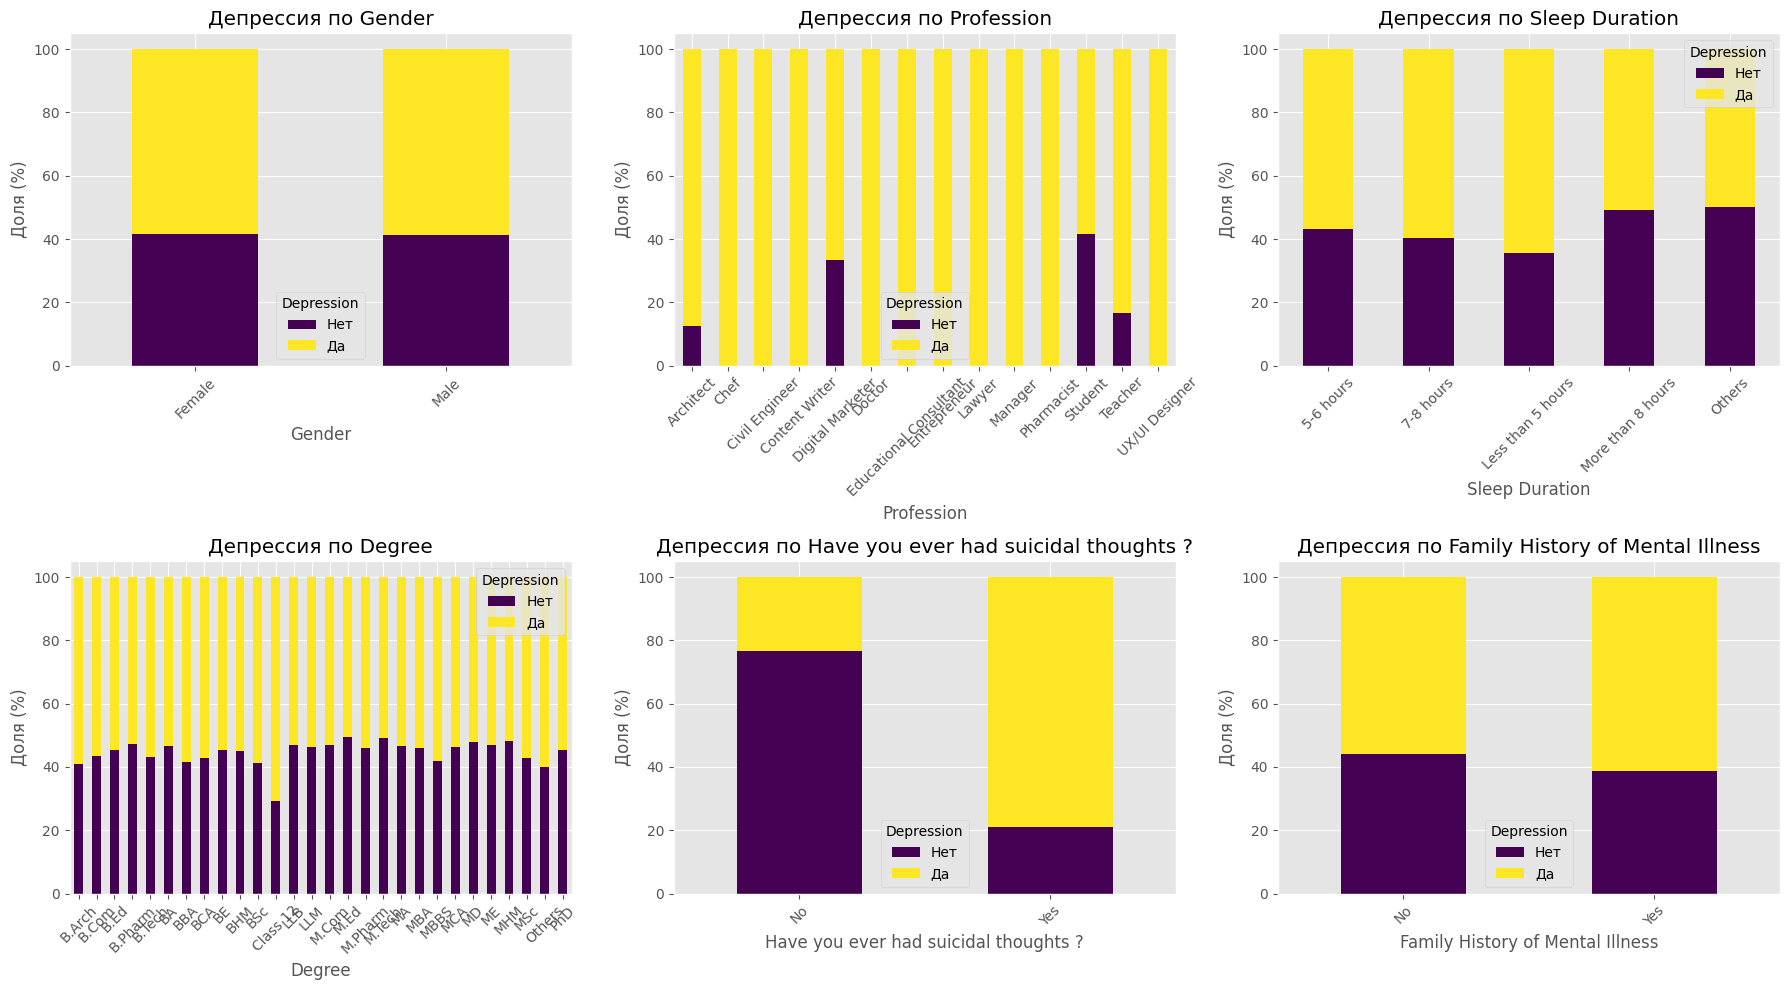

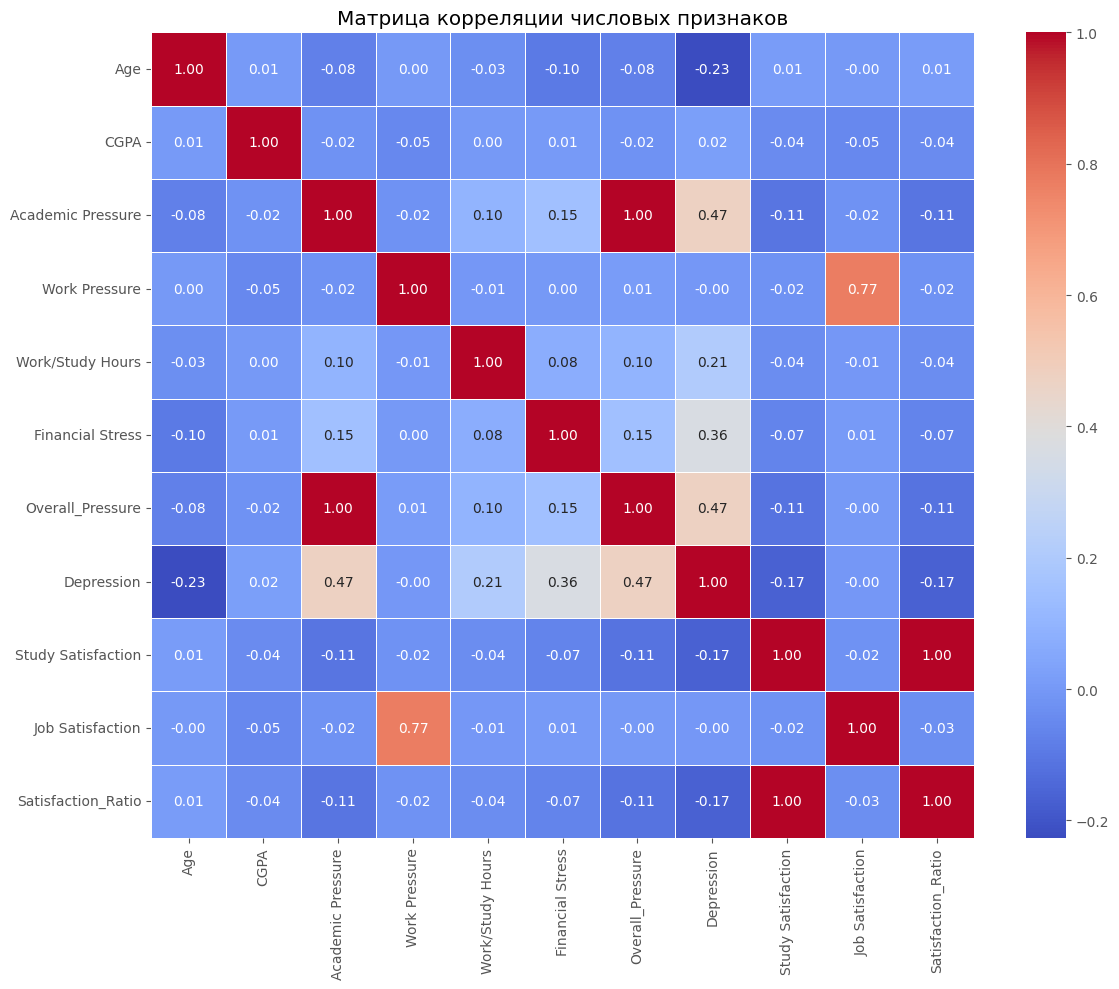

In [7]:
# Все графики сохраняются в report/images/
run_all_plots(df, save_dir=images_dir)

## 6. Разделение данных и сохранение

Стратегия сплита **Train 70% / Val 15% / Test 15%** с стратификацией по целевой переменной.

**Предотвращение data leakage:** сплит выполняется до любого кодирования признаков; `ColumnTransformer` в `modeling.py` обучается только на Train.

In [8]:
train_df, val_df, test_df = split_and_save(df, project_root=project_root)

print('\nРаспределение целевой переменной в сплитах:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    ratio = split['Depression'].mean()
    print(f'  {name}: {len(split)} строк | депрессия = {ratio:.2%}')

Train: 19528 | Val: 4185 | Test: 4185
Файлы сохранены в data/processed/

Распределение целевой переменной в сплитах:
  Train: 19528 строк | депрессия = 58.55%
  Val: 4185 строк | депрессия = 58.57%
  Test: 4185 строк | депрессия = 58.54%
